# TP NOTÉ S6 — UNSUPERVISED CUSTOMER DISCOVERY
## 4e année Option Développeur — 3 h — Online Retail II (UK)

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Mission — 5 pts

Vous recevez des transactions d'un retailer britannique. **Aucune cible de segmentation ne vous est fournie.**

Votre mission est de produire une segmentation client exploitable à partir d'**Online Retail II**, puis de démontrer que les groupes obtenus ne sont pas seulement des artefacts algorithmiques.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sheets = pd.read_excel("../../data/online_retail_II.xlsx", sheet_name=None)
df_raw = pd.concat(sheets.values(), ignore_index=True)

# normalisation minimale : minuscules + espaces->underscore, sans renommer semantiquement
df_raw.columns = [c.strip().lower().replace(' ', '_') for c in df_raw.columns]
df_raw['invoicedate'] = pd.to_datetime(df_raw['invoicedate'])

print(df_raw.shape)
print(df_raw.columns.tolist())
df_raw.head(3)

(1067371, 8)
['invoice', 'stockcode', 'description', 'quantity', 'invoicedate', 'price', 'customer_id', 'country']


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [2]:
print(df_raw['country'].value_counts().head(10))

df_uk = df_raw[df_raw['country'] == 'United Kingdom'].copy()
print("UK :", df_uk.shape)

country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64
UK : (981330, 8)


## De la transaction au client — 20 pts

Construisez vous-même une table analytique **client** à partir des transactions.

Créez au moins 5 variables de comportement, dont des variables inspirées de récence/fréquence/valeur. Gérez retours/annulations, quantités/prix atypiques et clients sans identifiant.

Chaque feature doit avoir une définition métier et une justification.

In [3]:
n_before = len(df_uk)
n_missing_cust = df_uk['customer_id'].isna().sum()
print(f"Clients sans identifiant : {n_missing_cust} ({n_missing_cust/n_before*100:.2f}%)")

df_uk = df_uk.dropna(subset=['customer_id']).copy()
df_uk['customer_id'] = df_uk['customer_id'].astype(int)

df_uk['is_cancel'] = df_uk['invoice'].astype(str).str.startswith('C')
print(f"Annulations : {df_uk['is_cancel'].sum()} ({df_uk['is_cancel'].mean()*100:.2f}%)")

n_before_price = len(df_uk)
n_bad_price = (df_uk['price'] <= 0).sum()
print(f"Lignes prix <= 0 (ajustements comptables, pas des ventes) : {n_bad_price} ({n_bad_price/n_before_price*100:.2f}%)")
df_uk = df_uk[df_uk['price'] > 0].copy()

# commandes geantes annulees quelques minutes apres (erreurs de saisie) : on retire la commande ET son annulation
giant = df_uk['quantity'].abs() >= 50000
print(df_uk.loc[giant, ['invoice','customer_id','quantity','price','invoicedate']])
print(f"Lignes supprimees (commandes geantes annulees) : {giant.sum()}")
df_uk = df_uk[~giant].copy()

print("Quantite describe:")
print(df_uk['quantity'].describe())
print(f"Shape finale ligne-transaction : {df_uk.shape}")

Clients sans identifiant : 240029 (24.46%)
Annulations : 16005 (2.16%)
Lignes prix <= 0 (ajustements comptables, pas des ventes) : 46 (0.01%)
         invoice  customer_id  quantity  price         invoicedate
587080    541431        12346     74215   1.04 2011-01-18 10:01:00
587085   C541433        12346    -74215   1.04 2011-01-18 10:17:00
1065882   581483        16446     80995   2.08 2011-12-09 09:15:00
1065883  C581484        16446    -80995   2.08 2011-12-09 09:27:00
Lignes supprimees (commandes geantes annulees) : 4
Quantite describe:
count    741251.000000
mean         11.251239
std          58.828335
min       -9360.000000
25%           2.000000
50%           4.000000
75%          12.000000
max       10000.000000
Name: quantity, dtype: float64
Shape finale ligne-transaction : (741251, 9)


In [4]:
# recency/frequency/monetary + variables de comportement complementaires
df_uk['line_amount'] = df_uk['quantity'] * df_uk['price']  # negatif pour les annulations

snapshot_date = df_uk['invoicedate'].max() + pd.Timedelta(days=1)
print("Date de reference (snapshot) :", snapshot_date)

purchases = df_uk[~df_uk['is_cancel']]

customer = df_uk.groupby('customer_id').agg(
    recency_days=('invoicedate', lambda s: (snapshot_date - s.max()).days),       
    frequency=('invoice', pd.Series.nunique),                                   
    monetary=('line_amount', 'sum'),                                                
    tenure_days=('invoicedate', lambda s: (s.max() - s.min()).days),              
    n_distinct_products=('stockcode', pd.Series.nunique),                         
    total_items=('quantity', 'sum'),                                                
    cancel_rate=('is_cancel', 'mean'),                                            
).reset_index()

avg_basket = purchases.groupby('customer_id')['line_amount'].sum() / purchases.groupby('customer_id')['invoice'].nunique()
customer = customer.merge(avg_basket.rename('avg_basket_value'), on='customer_id', how='left')
customer['avg_basket_value'] = customer['avg_basket_value'].fillna(0)

print(customer.shape)
customer.describe().round(2)

Date de reference (snapshot) : 2011-12-10 12:49:00
(5407, 9)


,customer_id,recency_days,frequency,monetary,tenure_days,n_distinct_products,total_items,cancel_rate,avg_basket_value
count,5407.00,5407.00,5407.00,5407.00,5407.00,5407.00,5407.00,5407.00,5407.00
mean,15557.90,204.70,7.49,2553.43,277.88,80.91,1542.44,0.04,344.90
std,1582.17,212.33,14.57,11348.51,260.23,112.17,6010.81,0.12,477.88
min,12346.00,1.00,1.00,-25111.09,0.00,1.00,-1085.00,0.00,0.00
25%,14188.50,25.00,2.00,314.71,0.00,18.00,175.00,0.00,173.19
50%,15569.00,99.00,4.00,815.90,230.00,44.00,458.00,0.00,272.93
75%,16926.50,383.00,8.00,2111.48,520.00,102.00,1276.00,0.03,398.10
max,18287.00,739.00,364.00,598215.22,738.00,2286.00,187110.00,1.00,14844.77


| feature | définition métier | justification |
| :--- | :--- | :--- |
| `recency_days` | jours depuis le dernier achat (au 10/12/2011) | R de RFM : un client récent rachète plus souvent |
| `frequency` | nombre de factures distinctes | F de RFM : mesure la fidélité |
| `monetary` | chiffre d'affaires net (achats − retours) | M de RFM : valeur du client |
| `tenure_days` | jours entre le premier et le dernier achat | ancienneté de la relation client |
| `n_distinct_products` | nombre de références différentes achetées | largeur du panier, distingue revendeurs et acheteurs ciblés |
| `total_items` | quantité nette d'articles | volume, repère les grossistes |
| `cancel_rate` | part des lignes annulées | comportement de retour, signal de risque |
| `avg_basket_value` | CA moyen par facture, hors annulations | taille du panier |

## K-Means — 20 pts

Préparez les données puis testez plusieurs K. Utilisez au moins deux arguments pour sélectionner K (ex. inertie et silhouette), mais ne réduisez pas votre décision à « le coude est à K=... ».

Profilez chaque cluster sur les variables originales.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

feature_cols = ['recency_days','frequency','monetary','tenure_days',
                 'n_distinct_products','total_items','cancel_rate','avg_basket_value']
Xc = customer[feature_cols].copy()
# variables tres asymetriques (skew > 5) : log1p pour eviter que quelques clients extremes dictent les clusters
print("Skew avant log :"); print(customer[feature_cols].skew().round(1))
for c in ['recency_days','frequency','monetary','n_distinct_products','total_items','avg_basket_value']:
    Xc[c] = np.log1p(Xc[c].clip(lower=0))

scaler = StandardScaler()
Xs = scaler.fit_transform(Xc)

k_results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(Xs)
    k_results.append(dict(k=k, inertia=km.inertia_, silhouette=silhouette_score(Xs, labels),
                           plus_petit_cluster=int(np.bincount(labels).min())))

k_results_df = pd.DataFrame(k_results)
k_results_df

Skew avant log :
recency_days            0.9
frequency               9.9
monetary               31.7
tenure_days             0.4
n_distinct_products     5.2
total_items            17.5
cancel_rate             6.3
avg_basket_value       16.9
dtype: float64


,k,inertia,silhouette,plus_petit_cluster
0,2,26865.576238,0.356014,2549
1,3,19248.655553,0.377045,90
2,4,15709.439114,0.275354,88
3,5,13990.750765,0.222744,87
4,6,12807.940697,0.225676,87
5,7,11805.142788,0.231011,45
6,8,10938.700085,0.210346,45


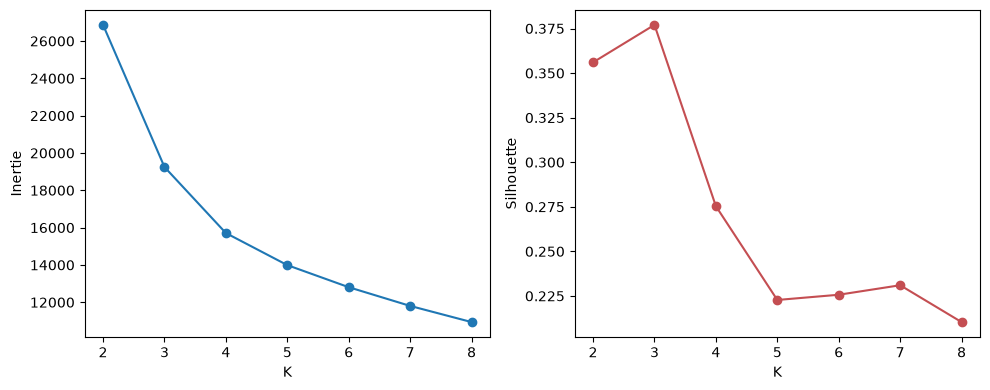

K retenu : 3


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(k_results_df['k'], k_results_df['inertia'], marker='o')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertie')
axes[1].plot(k_results_df['k'], k_results_df['silhouette'], marker='o', color='#C44E52')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

# argument 1 : silhouette maximale ; argument 2 : aucun cluster de moins de 1 % des clients (sinon segment inexploitable)
eligibles = k_results_df[k_results_df['plus_petit_cluster'] >= 0.01 * len(customer)]
best_k = int(eligibles.loc[eligibles['silhouette'].idxmax(), 'k'])
print("K retenu :", best_k)

In [7]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
customer['cluster_kmeans'] = kmeans_final.fit_predict(Xs)

profile_kmeans = customer.groupby('cluster_kmeans')[feature_cols].mean().round(2)
profile_kmeans['n_clients'] = customer['cluster_kmeans'].value_counts().sort_index()
profile_kmeans

,recency_days,frequency,monetary,tenure_days,n_distinct_products,total_items,cancel_rate,avg_basket_value,n_clients
cluster_kmeans,,,,,,,,,
0,72.17,14.11,5214.69,503.45,146.83,3135.63,0.03,426.27,2398
1,517.71,1.93,-897.47,34.69,3.74,-25.51,0.85,238.40,90
2,303.92,2.22,473.57,100.07,29.13,281.97,0.02,281.33,2919


K = 3 maximise la silhouette (0,377) parmi les K dont aucun cluster ne fait moins de 1 % des clients, et l'inertie baisse ensuite beaucoup moins (−28 % de K = 2 à 3, −18 % de 3 à 4) ; les trois clusters sont les actifs fidèles (2 398 clients, 72 jours, 14 commandes, 5 215 £), les occasionnels inactifs (2 919, 304 jours, 2 commandes, 474 £) et les retours seuls (90, 85 % d'annulations, CA négatif).

## CAH & DBSCAN — 20 pts

Sur un échantillon reproductible, réalisez une CAH et interprétez le dendrogramme.

Appliquez ensuite DBSCAN. Justifiez la recherche de `eps` et `min_samples`. Quantifiez les points bruités.

Comparez structurellement les résultats des trois méthodes.

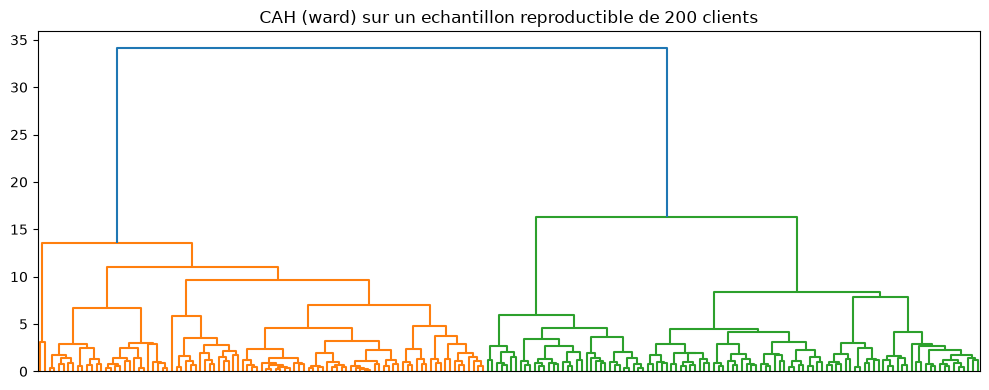

Tailles des clusters CAH :
1    95
2    34
3    71
Name: count, dtype: int64


In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

SAMPLE_SIZE = min(200, len(customer))
sample_positions = customer.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).index
Xs_sample = Xs[customer.index.get_indexer(sample_positions)]

Z = linkage(Xs_sample, method='ward')

fig, ax = plt.subplots(figsize=(10,4))
dendrogram(Z, no_labels=True, ax=ax)
ax.set_title(f"CAH (ward) sur un echantillon reproductible de {SAMPLE_SIZE} clients")
plt.tight_layout()
plt.show()

N_CLUSTERS_CAH = best_k
clusters_cah = fcluster(Z, t=N_CLUSTERS_CAH, criterion='maxclust')
print("Tailles des clusters CAH :")
print(pd.Series(clusters_cah).value_counts().sort_index())

Le plus grand saut de fusion (d'environ 16 à 34) sépare deux grands groupes, et la coupe juste en dessous en donne trois, ce qui est cohérent avec K = 3 ; en dessous d'une hauteur de 10, les fusions sont petites et ne forment pas de groupes nets.

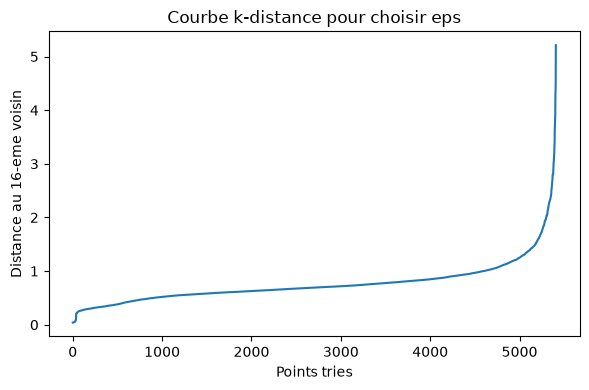

min_samples = 16 (2x le nombre de dimensions)
eps = 1.143 (90e percentile de la courbe k-distance)
DBSCAN : 2 cluster(s), 232 points bruites (4.29%)


In [9]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 2 * Xs.shape[1]  # heuristique standard : 2 x dimension
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Xs)
distances, _ = nbrs.kneighbors(Xs)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(k_dist)
ax.set_xlabel("Points tries"); ax.set_ylabel(f"Distance au {MIN_SAMPLES}-eme voisin")
ax.set_title("Courbe k-distance pour choisir eps")
plt.tight_layout()
plt.show()

EPS = float(np.percentile(k_dist, 90))  # coude approx. : 90e percentile de la k-distance
print(f"min_samples = {MIN_SAMPLES} (2x le nombre de dimensions)")
print(f"eps = {EPS:.3f} (90e percentile de la courbe k-distance)")

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(Xs)
customer['cluster_dbscan'] = db.labels_
n_noise = (db.labels_ == -1).sum()
n_clusters_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f"DBSCAN : {n_clusters_db} cluster(s), {n_noise} points bruites ({n_noise/len(db.labels_)*100:.2f}%)")

`min_samples = 16` (2 × 8 dimensions) et `eps = 1,14` placé au début du coude de la courbe k-distance (la distance augmente brutalement après environ 5 000 points), ce qui donne 232 points bruités (4,29 %).

In [10]:
from sklearn.metrics import adjusted_rand_score

cah_full = pd.Series(index=customer.index, dtype='float')
cah_full.loc[sample_positions] = clusters_cah
comparison_sample = customer.loc[sample_positions, ['cluster_kmeans']].copy()
comparison_sample['cluster_cah'] = clusters_cah

ari_kmeans_cah = adjusted_rand_score(comparison_sample['cluster_kmeans'], comparison_sample['cluster_cah'])
ari_kmeans_dbscan = adjusted_rand_score(customer['cluster_kmeans'], customer['cluster_dbscan'])

print(f"ARI KMeans vs CAH (sur l'echantillon commun)  : {ari_kmeans_cah:.3f}")
print(f"ARI KMeans vs DBSCAN (sur tous les clients)   : {ari_kmeans_dbscan:.3f}")
print(pd.crosstab(comparison_sample['cluster_kmeans'], comparison_sample['cluster_cah']))
print()
print(pd.crosstab(customer['cluster_kmeans'], customer['cluster_dbscan']))

ARI KMeans vs CAH (sur l'echantillon commun)  : 0.469
ARI KMeans vs DBSCAN (sur tous les clients)   : 0.058
cluster_cah      1   2   3
cluster_kmeans            
0                2  34  49
1                2   0   0
2               91   0  22

cluster_dbscan   -1     0   1
cluster_kmeans               
0                94  2304   0
1                34     0  56
2               104  2815   0


K-Means et CAH concordent moyennement (ARI 0,47) et isolent toutes deux le groupe des retours, alors que DBSCAN (ARI 0,06) réunit actifs et occasionnels dans un seul groupe dense (2 304 + 2 815 clients) et classe 232 clients en bruit : la séparation actifs/occasionnels est un gradient plutôt qu'une frontière naturelle.

## PCA / t-SNE — 15 pts

Utilisez PCA puis t-SNE pour explorer la structure. Pour PCA, quantifiez la variance expliquée. Pour t-SNE, testez au moins deux configurations.

Expliquez explicitement ce qu'on **ne peut pas conclure** d'une carte t-SNE.

Variance expliquee cumulee par composante :
  1 composantes : 60.2%
  2 composantes : 78.1%
  3 composantes : 85.8%
  4 composantes : 91.3%
  5 composantes : 95.6%
  6 composantes : 98.3%
  7 composantes : 99.5%
  8 composantes : 100.0%

Variance expliquee par les 2 premieres composantes : 78.1%


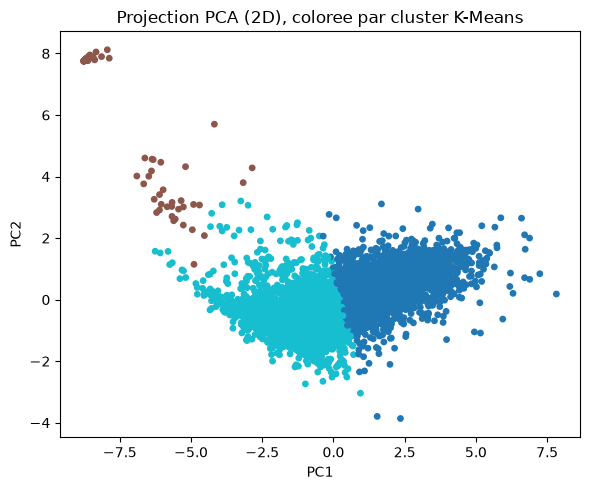

In [11]:
from sklearn.decomposition import PCA

pca_full = PCA(n_components=Xs.shape[1], random_state=RANDOM_STATE).fit(Xs)
explained = np.cumsum(pca_full.explained_variance_ratio_)
print("Variance expliquee cumulee par composante :")
for i, v in enumerate(explained, start=1):
    print(f"  {i} composantes : {v*100:.1f}%")

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(Xs)
print(f"\nVariance expliquee par les 2 premieres composantes : {pca2.explained_variance_ratio_.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(6,5))
sc = ax.scatter(X_pca2[:,0], X_pca2[:,1], c=customer['cluster_kmeans'], cmap='tab10', s=15)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Projection PCA (2D), coloree par cluster K-Means')
plt.tight_layout()
plt.show()

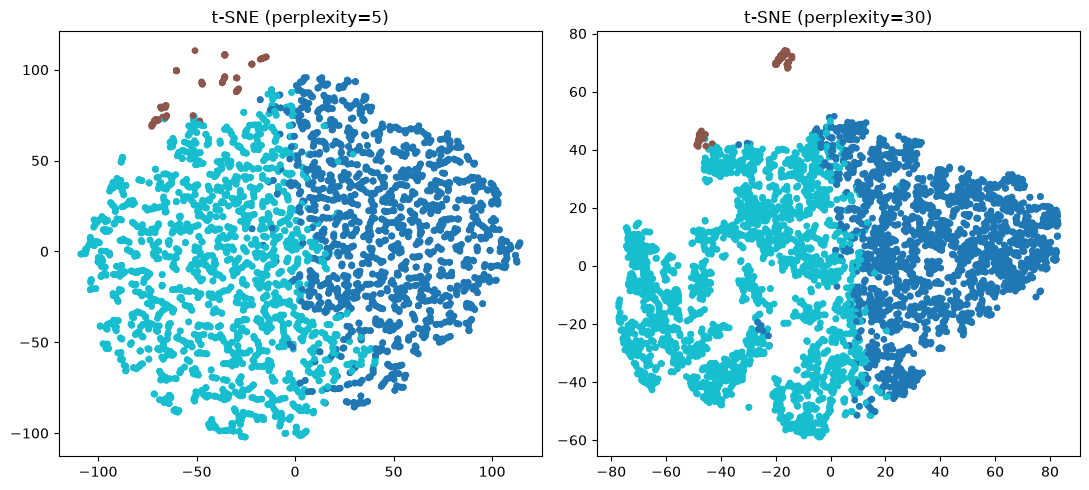

Ce qu'on NE PEUT PAS conclure d'une carte t-SNE :
- les distances entre points eloignes sur la carte ne reflètent pas les distances reelles dans l'espace d'origine ;
- la taille apparente d'un groupe sur la carte n'est pas proportionnelle a sa densite ou son importance reelle ;
- deux configurations avec des perplexites differentes (ci-dessus) peuvent donner des formes globales differentes pour les memes donnees ;
- t-SNE ne fournit pas un nombre de clusters ni une frontiere de decision : c'est un outil de visualisation, pas une methode de clustering.


In [12]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 2, figsize=(11,5))
for ax, perplexity in zip(axes, [5, 30]):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=RANDOM_STATE, init='pca')
    X_tsne = tsne.fit_transform(Xs)
    sc = ax.scatter(X_tsne[:,0], X_tsne[:,1], c=customer['cluster_kmeans'], cmap='tab10', s=15)
    ax.set_title(f"t-SNE (perplexity={perplexity})")
plt.tight_layout()
plt.show()

print("Ce qu'on NE PEUT PAS conclure d'une carte t-SNE :")
print("- les distances entre points eloignes sur la carte ne reflètent pas les distances reelles dans l'espace d'origine ;")
print("- la taille apparente d'un groupe sur la carte n'est pas proportionnelle a sa densite ou son importance reelle ;")
print("- deux configurations avec des perplexites differentes (ci-dessus) peuvent donner des formes globales differentes pour les memes donnees ;")
print("- t-SNE ne fournit pas un nombre de clusters ni une frontiere de decision : c'est un outil de visualisation, pas une methode de clustering.")

## Anomaly investigation — 10 pts

Utilisez une méthode de détection d'anomalies. Analysez individuellement au moins 10 clients signalés.

Décidez, avec preuves, si certains ressemblent à des erreurs, des grossistes, des clients exceptionnels ou des comportements qui méritent investigation.

In [13]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=RANDOM_STATE)
customer['anomaly'] = iso.fit_predict(Xs)
customer['anomaly_score'] = iso.decision_function(Xs)

n_anom = (customer['anomaly'] == -1).sum()
print(f"Clients signales comme anomalies : {n_anom} ({n_anom/len(customer)*100:.2f}%)")

anomalies = customer[customer['anomaly'] == -1].sort_values('anomaly_score')
# 6 anomalies les plus fortes cote valeur negative/nulle + 6 cote valeur positive, pour couvrir les deux types de profils
top_anomalies = pd.concat([anomalies[anomalies['monetary'] <= 0].head(6), anomalies[anomalies['monetary'] > 0].head(6)])
cols_show = ['customer_id'] + feature_cols + ['cluster_kmeans', 'anomaly_score']
top_anomalies[cols_show]

Clients signales comme anomalies : 109 (2.02%)


,customer_id,recency_days,frequency,monetary,tenure_days,n_distinct_products,total_items,cancel_rate,avg_basket_value,cluster_kmeans,anomaly_score
2899,15767,641,2,-242.70,94,9,-50,1.000000,0.000000,1,-0.077994
1497,14337,731,1,-658.63,0,36,-393,1.000000,0.000000,1,-0.071077
4878,17755,424,1,-72.23,0,10,-30,1.000000,0.000000,1,-0.068715
4007,16879,420,2,-140.96,18,2,-2,1.000000,0.000000,1,-0.068070
4609,17485,738,1,-29.55,0,6,-9,1.000000,0.000000,1,-0.066790
2342,15202,420,8,-2570.18,2,1,-2,0.625000,2000.496667,1,-0.064054
3582,16454,45,8,1.90,630,5,5,0.500000,7.737500,1,-0.060151
4634,17511,3,85,171885.98,734,678,117913,0.104499,2926.725833,0,-0.058027
5222,18102,1,153,598215.22,738,384,187110,0.009363,4198.770000,0,-0.047790
5069,17949,1,138,98895.59,736,59,54328,0.142077,1005.322712,0,-0.043518


In [14]:
# Classification descriptive des anomalies examinees individuellement (regles explicites, verifiables)
def classify_anomaly(row):
    if row['cancel_rate'] == 1:
        return "retours seuls : achat anterieur a la periode (historique tronque)"
    if row['cancel_rate'] > 0.3:
        return "possible erreur / forte proportion de retours"
    if row['total_items'] > customer['total_items'].quantile(0.95) or row['frequency'] > customer['frequency'].quantile(0.95):
        return "probable grossiste (volume/frequence eleves)"
    if row['monetary'] > customer['monetary'].quantile(0.95):
        return "client exceptionnel (tres forte valeur)"
    return "a investiguer (profil atypique sans explication evidente)"

top_anomalies = top_anomalies.copy()
top_anomalies['hypothese'] = top_anomalies.apply(classify_anomaly, axis=1)
print(top_anomalies[['customer_id','frequency','monetary','total_items','cancel_rate','hypothese']].to_string(index=False))
print()
print(top_anomalies['hypothese'].value_counts())
print()
print("Sur l'ensemble des", n_anom, "anomalies :")
print(anomalies.apply(classify_anomaly, axis=1).value_counts())

 customer_id  frequency  monetary  total_items  cancel_rate                                                         hypothese
       15767          2   -242.70          -50     1.000000 retours seuls : achat anterieur a la periode (historique tronque)
       14337          1   -658.63         -393     1.000000 retours seuls : achat anterieur a la periode (historique tronque)
       17755          1    -72.23          -30     1.000000 retours seuls : achat anterieur a la periode (historique tronque)
       16879          2   -140.96           -2     1.000000 retours seuls : achat anterieur a la periode (historique tronque)
       17485          1    -29.55           -9     1.000000 retours seuls : achat anterieur a la periode (historique tronque)
       15202          8  -2570.18           -2     0.625000                     possible erreur / forte proportion de retours
       16454          8      1.90            5     0.500000                     possible erreur / forte proportion de 

Sur les 12 clients examinés, 5 sont des retours d'achats antérieurs à décembre 2009 (100 % d'annulations, aucun achat dans la période), 2 ressemblent à des erreurs ou ajustements (15202 : un seul produit, CA net de −2 570 £ pour 2 articles) et 5 sont des grossistes probables (47 000 à 187 000 articles, jusqu'à 598 215 £), à traiter à part des campagnes.

## Executive segmentation memo — 5 pts

Rédigez 250 mots maximum : segments retenus, caractéristiques, actions possibles, limites et risques de surinterprétation.

**Mémo — segmentation des 5 407 clients identifiés (UK)**

- **Actifs fidèles — 2 398 clients (44 %)** : dernier achat il y a 72 jours en moyenne, 14 commandes, 5 215 £ de CA net, 147 références achetées. *Action :* programme de fidélité et ventes additionnelles.
- **Occasionnels inactifs — 2 919 clients (54 %)** : dernier achat il y a 304 jours, 2 commandes, 474 £. *Action :* campagne de réactivation, avec mesure de son effet.
- **Retours seuls — 90 clients (2 %)** : 85 % de lignes annulées et CA net négatif, surtout des retours d'achats antérieurs à décembre 2009. *Action :* exclure des campagnes, contrôle par le service client.
- **Hors segments** : 109 anomalies (Isolation Forest), dont 22 grossistes probables (jusqu'à 598 215 £) à confier à un commercial dédié.

**Limites et risques :** 24,5 % des lignes UK n'ont pas d'identifiant client et sont exclues ; la partition dépend du passage au log et de la standardisation ; K-Means et CAH ne concordent que moyennement (ARI 0,47) et DBSCAN voit surtout un continuum (ARI 0,06), donc la frontière entre actifs et occasionnels est graduelle ; les cartes t-SNE ne prouvent pas l'existence des segments.

## Reproductibilité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.